# Data Collection

In [1]:
# Load libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

file_path = "/content/drive/MyDrive/Master thesis/merged_artists.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (101226, 46)


,Artist Name,Country,Genre,Label,Viberate Rank,Spotify Rank,Spotify Followers Total,Spotify Streams Total,Spotify Monthly Listeners Total,Spotify Playlist Reach Total,...,Instagram Likes 1m,Facebook Followers 1m,Deezer Fans 1m,SoundCloud Followers 1m,SoundCloud Plays 1m,Shazam Shazams 1m,Radio Airplay Spins 1m,Radio Airplay Countries with Spins 1m,Radio Airplay Stations with Spins 1m,Beatport Track Performance Points 1m
0,Moliy,Ghana,African,"Big Indie Labels, Sony Music Entertainment, Un...",1297.0,1201.0,259373.0,1.160112e+09,11951295.0,86354352.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amaarae,Ghana,R&B,"Universal Music Group, Warner Music Group, Son...",4589.0,2714.0,610701.0,1.376583e+09,5259973.0,36449115.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Blaqbonez,Nigeria,Hip Hop,"Big Indie Labels, Universal Music Group, Warne...",6535.0,7528.0,1281464.0,3.472101e+08,1412483.0,8119279.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fimiguerrero,United Kingdom,Hip Hop,"Big Indie Labels, Sony Music Entertainment, Un...",6940.0,6265.0,174136.0,2.475404e+08,3298359.0,7569899.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Poco Lee,Nigeria,African,"Big Indie Labels, Warner Music Group",8522.0,14398.0,376708.0,6.108530e+07,855002.0,1753597.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Initial look

In [3]:
example_artist = df.loc[df["Viberate Rank"].idxmin()]
example_artist = example_artist.apply(lambda x: int(x) if isinstance(x, float) and x.is_integer() else x)

example_artist.to_frame(name="Value")

,Value
Artist Name,Bad Bunny
Country,Puerto Rico
Genre,Latin
Label,"Big Indie Labels, Sony Music Entertainment, Wa..."
Viberate Rank,1
Spotify Rank,5
Spotify Followers Total,109744269
Spotify Streams Total,116046763809
Spotify Monthly Listeners Total,110351500
Spotify Playlist Reach Total,601530450


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing": missing, "missing_%": missing_pct})
missing_table.head(30)

,missing,missing_%
Beatport Track Performance Points 1m,78143,77.20
Beatport Track Performance Points Total,76706,75.78
Beatport Days in Top 100 Total,76706,75.78
Beatport Tracks in Top 100 Total,76706,75.78
Beatport Tracks Total,76706,75.78
Beatport Rank,75834,74.92
TikTok Followers 1m,62205,61.45
TikTok Views 1m,62065,61.31
TikTok Likes 1m,62065,61.31
TikTok Followers Total,60698,59.96


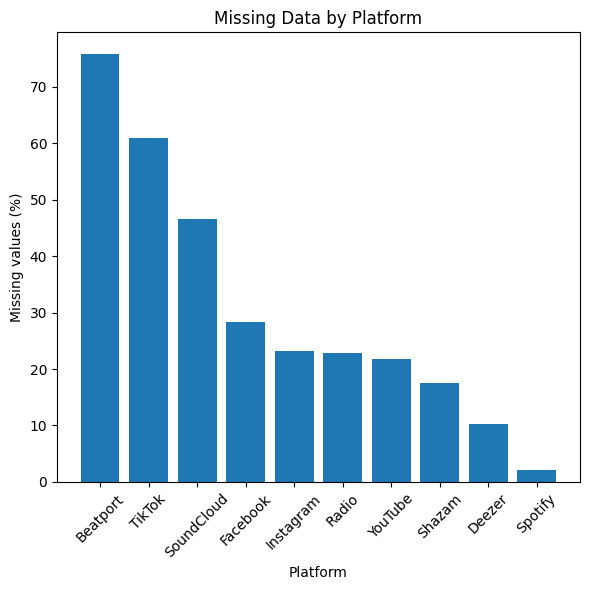

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

platforms = {
    "Spotify": [c for c in df.columns if "Spotify" in c],
    "YouTube": [c for c in df.columns if "YouTube" in c],
    "TikTok": [c for c in df.columns if "TikTok" in c],
    "Instagram": [c for c in df.columns if "Instagram" in c],
    "Facebook": [c for c in df.columns if "Facebook" in c],
    "SoundCloud": [c for c in df.columns if "SoundCloud" in c],
    "Deezer": [c for c in df.columns if "Deezer" in c],
    "Radio": [c for c in df.columns if "Radio" in c],
    "Beatport": [c for c in df.columns if "Beatport" in c],
    "Shazam": [c for c in df.columns if "Shazam" in c],
}

missing_platform = {}

for platform, cols in platforms.items():
    if cols:
        missing_platform[platform] = df[cols].isna().mean().mean() * 100

missing_platform = pd.Series(missing_platform).sort_values(ascending=False)

plt.figure(figsize=(6,6))

plt.bar(missing_platform.index, missing_platform.values)

plt.ylabel("Missing values (%)")
plt.xlabel("Platform")
plt.title("Missing Data by Platform")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

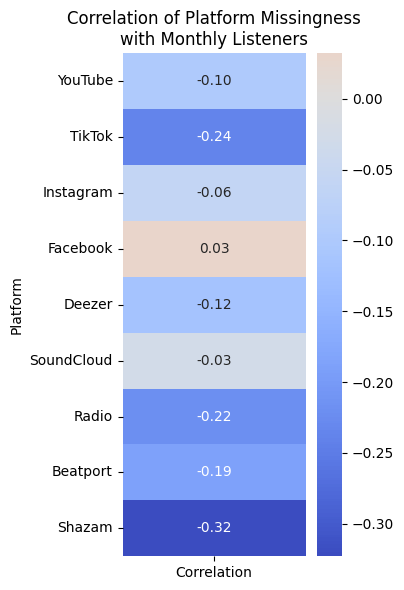

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

listener_col = "Spotify Monthly Listeners Total"

platforms = {
    "YouTube": [c for c in df.columns if "YouTube" in c],
    "TikTok": [c for c in df.columns if "TikTok" in c],
    "Instagram": [c for c in df.columns if "Instagram" in c],
    "Facebook": [c for c in df.columns if "Facebook" in c],
    "Deezer": [c for c in df.columns if "Deezer" in c],
    "SoundCloud": [c for c in df.columns if "SoundCloud" in c],
    "Radio": [c for c in df.columns if "Radio" in c],
    "Beatport": [c for c in df.columns if "Beatport" in c],
    "Shazam": [c for c in df.columns if "Shazam" in c],
}

corr_data = []

log_listeners = np.log1p(df[listener_col])

for platform, cols in platforms.items():
    if cols:
        missing_indicator = df[cols].isna().all(axis=1).astype(int)
        corr = missing_indicator.corr(log_listeners)
        corr_data.append([platform, corr])

heatmap_df = pd.DataFrame(corr_data, columns=["Platform", "Correlation"])
heatmap_df = heatmap_df.set_index("Platform")

plt.figure(figsize=(4, 6))
sns.heatmap(heatmap_df, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation of Platform Missingness\nwith Monthly Listeners")
plt.tight_layout()
plt.show()

# Univariate EDA

In [7]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].describe().T.sort_values("std", ascending=False).head(30)

,count,mean,std,min,25%,50%,75%,max
Spotify Streams Total,99636.0,3.370832e+08,2.168835e+09,1000.0,1413047.00,12433674.0,86408220.25,1.381801e+11
YouTube Views Total,81236.0,2.601323e+08,1.472389e+09,0.0,274149.00,5298780.0,72273149.75,7.041440e+10
Spotify Streams 1m,96706.0,4.871829e+06,2.970332e+07,0.0,15392.50,183075.0,1351389.00,2.519806e+09
Spotify Playlist Reach Total,99181.0,4.811187e+06,2.201307e+07,0.0,34015.00,257831.0,1764383.00,7.236531e+08
YouTube Likes Total,81236.0,2.473723e+06,1.939637e+07,0.0,3962.75,59610.5,616081.50,2.074185e+09
YouTube Views 1m,78963.0,2.106713e+06,1.234748e+07,-1073.0,945.50,29669.0,600739.00,8.309606e+08
Instagram Followers Total,79351.0,5.655706e+05,4.740917e+06,0.0,3748.00,20725.0,145217.00,4.152885e+08
Spotify Monthly Listeners Total,100411.0,8.657558e+05,3.680284e+06,0.0,4957.00,52266.0,339801.50,1.327424e+08
TikTok Views 1m,39161.0,4.861154e+05,3.465611e+06,-21252426.0,0.00,2577.0,118390.00,3.028744e+08
TikTok Followers Total,40528.0,5.457654e+05,2.612739e+06,1.0,1780.00,28660.0,246900.00,1.558400e+08


In [8]:
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(20))


 Artist Name
Artist Name
Sofia             5
Luna              4
Hamilton          4
Airbag            4
Haze              4
Essam Sasa        4
Celeste           4
Death             4
Mario             4
Kenny Haiti       4
Bilal Sghir       4
Pandora           4
Gabriel Guedes    4
Adam              4
Crowder           4
Nightmare         4
Shiva             4
Nicoleta Guta     3
Messiah           3
Florin Salam      3
Name: count, dtype: int64

 Country
Country
United States         23653
United Kingdom         7330
Brazil                 5606
Germany                4741
France                 3238
Japan                  2672
Italy                  2487
Spain                  2383
Mexico                 2377
Australia              2187
Canada                 2172
Netherlands            1743
Indonesia              1684
India                  1568
Argentina              1541
Sweden                 1525
Russian Federation     1261
Nigeria                1213
South Korea            121

### Distributions

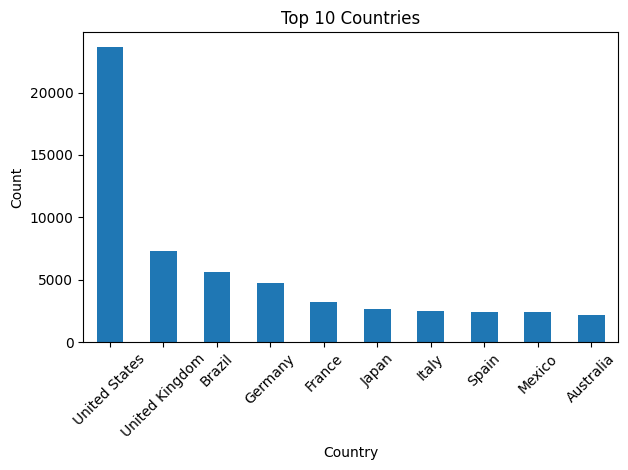

In [9]:
import matplotlib.pyplot as plt

top_countries = df["Country"].value_counts().head(10)

plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 10 Countries")
plt.ylabel("Count")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

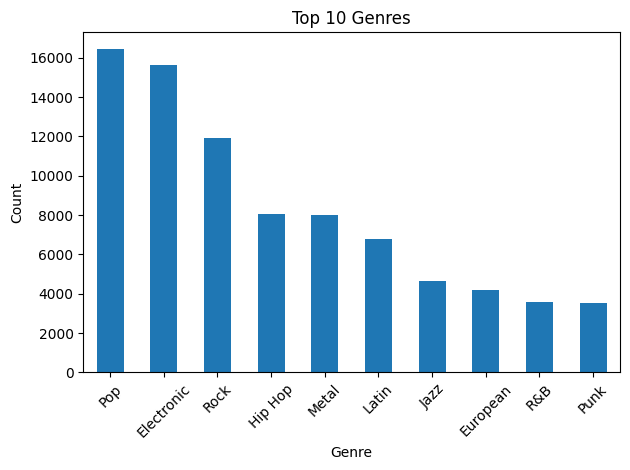

In [10]:
top_genres = df["Genre"].value_counts().head(10)

plt.figure()
top_genres.plot(kind="bar")
plt.title("Top 10 Genres")
plt.ylabel("Count")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Spotify Streams
Monthly Spotify Streams exhibit strong right-skewness.
A lo-transformation was applied to reduce skewness and stabilize variance.
The transformed distribution approximates normality, making it more suitable for predictive mdoeling.

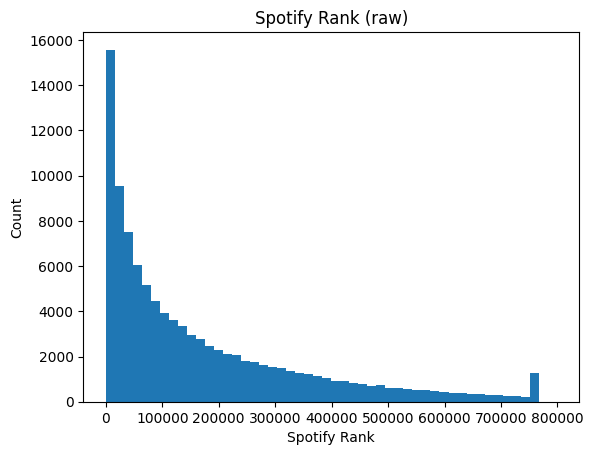

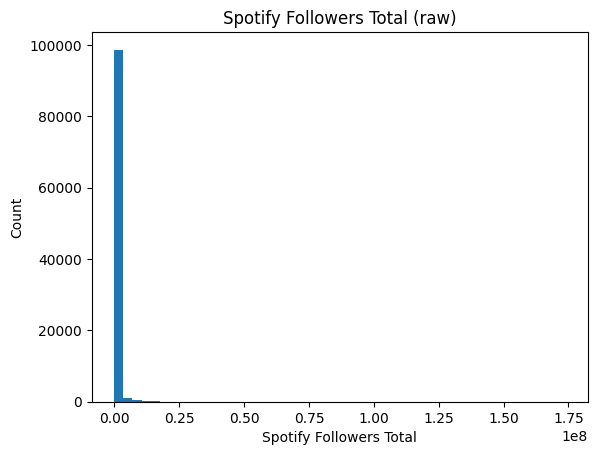

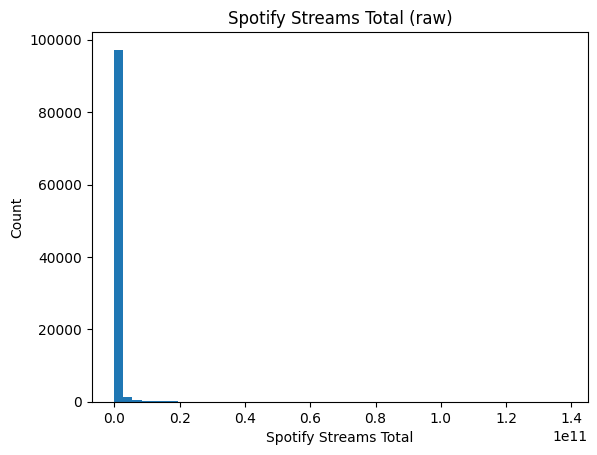

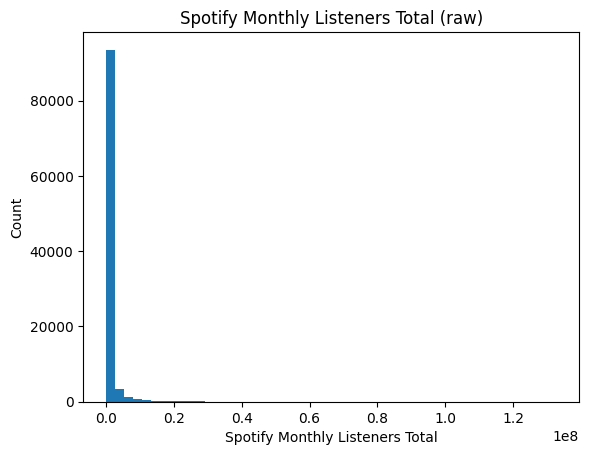

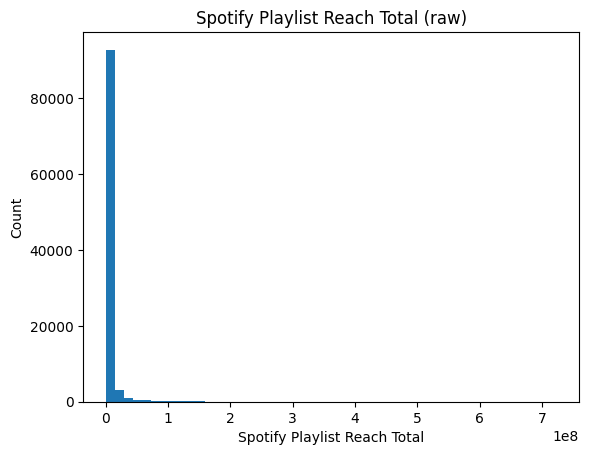

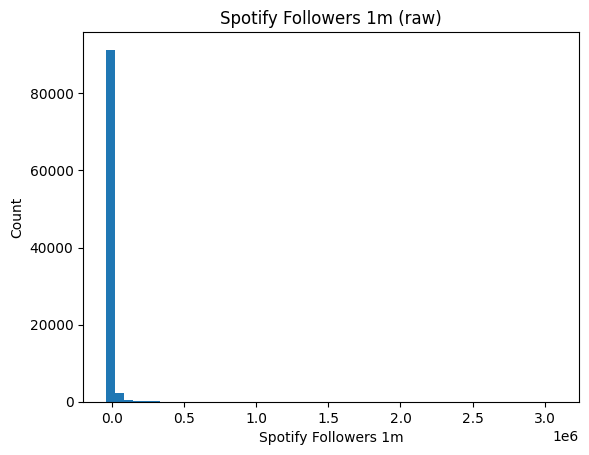

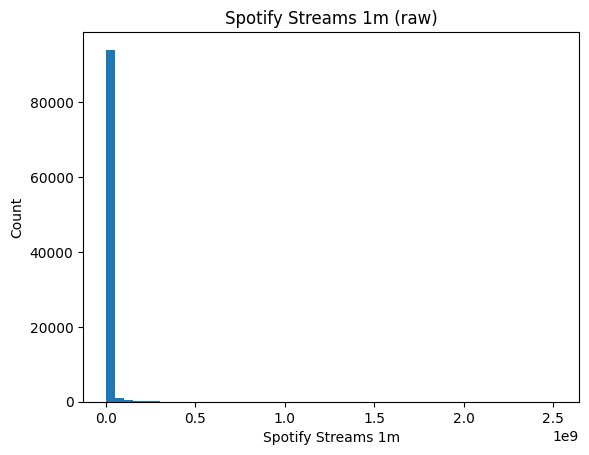

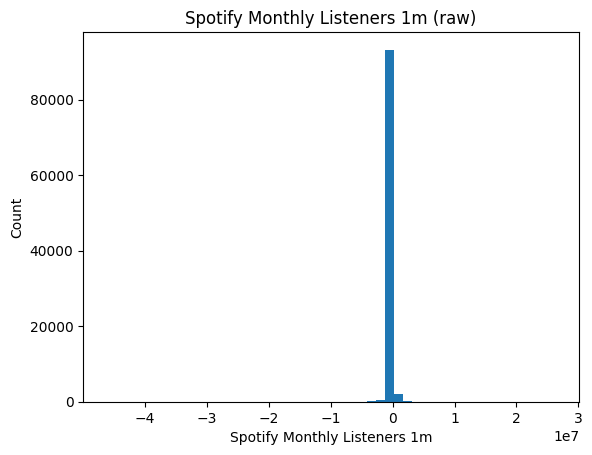

In [11]:
spotify_cols = [
    col for col in df.columns
    if "Spotify" in col and np.issubdtype(df[col].dtype, np.number)
]

spotify_cols

for col in spotify_cols:
    x = df[col].replace(0, np.nan).dropna()

    plt.figure()
    plt.hist(x, bins=50)
    plt.title(f"{col} (raw)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

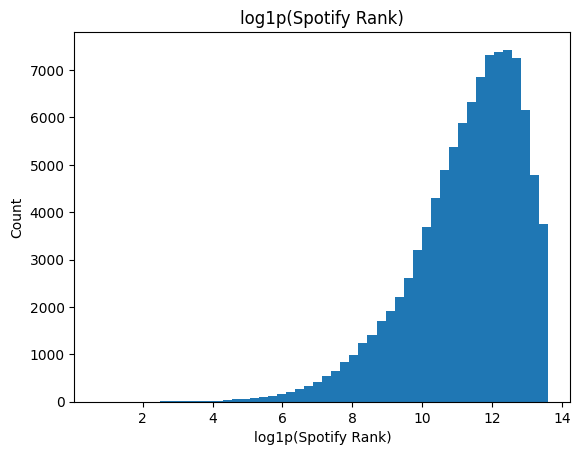

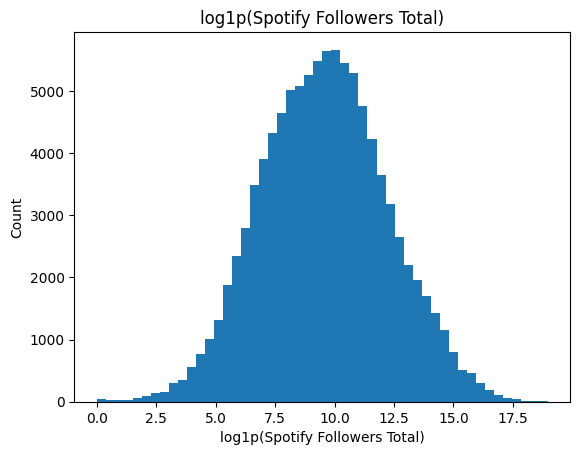

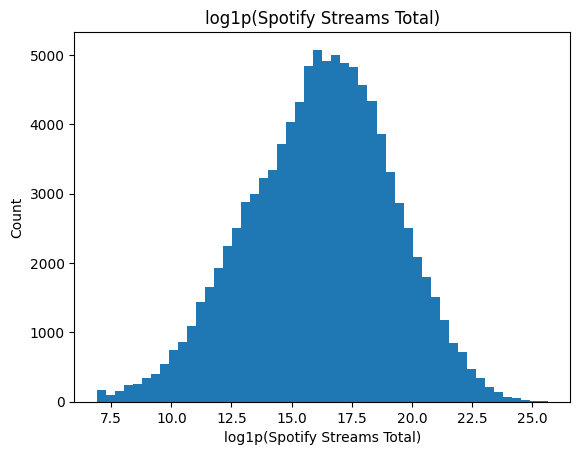

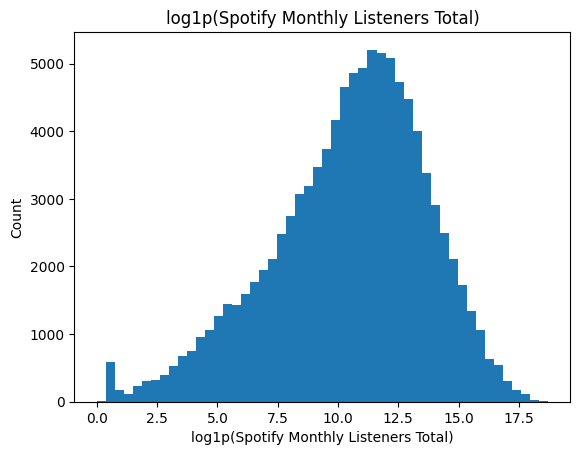

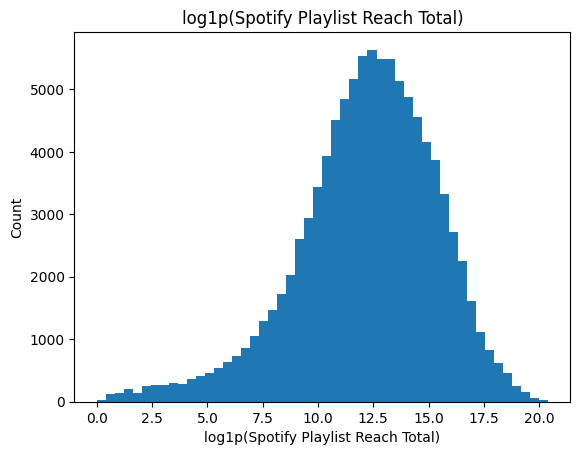

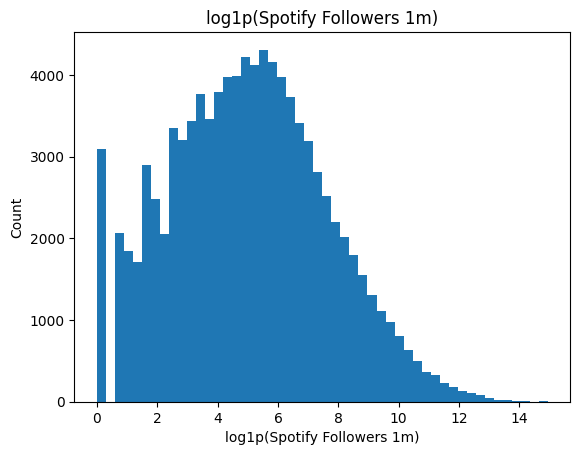

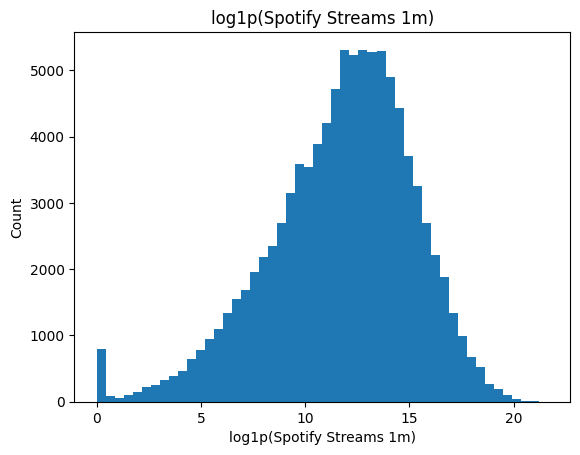

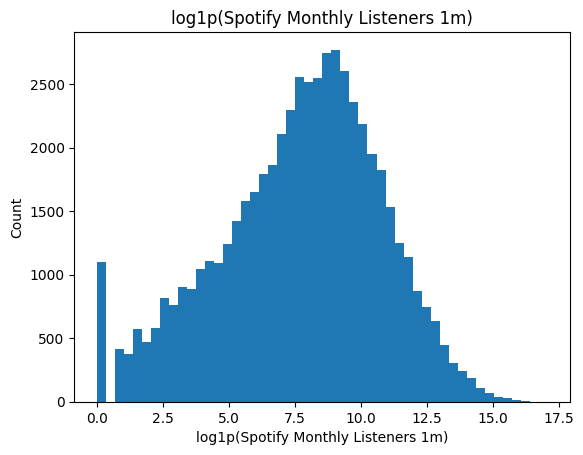

In [12]:
spotify_cols = [
    col for col in df.columns
    if "Spotify" in col and np.issubdtype(df[col].dtype, np.number)
]

for col in spotify_cols:
    x = df[col].copy()

    # Remove NaN
    x = x.dropna()

    # Keep only non-negative values (log1p requires x > -1)
    x = x[x >= 0]

    # Apply log1p
    x_log = np.log1p(x)

    # Remove any remaining infinite values
    x_log = x_log[np.isfinite(x_log)]

    if len(x_log) == 0:
        print(f"Skipping {col} (no valid values)")
        continue

    plt.figure()
    plt.hist(x_log, bins=50)
    plt.title(f"log1p({col})")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Count")
    plt.show()

# Bivariate EDA

**In general**
- Most artists are compressed around 0
- Mid-tier artists → highest variance and strongest spikes
- Non-linear relationship (funnel shape, curvature)

**Monthly listenters**
- Small artist have low momentum
- Mid-to-high have higher momentum

**Followers 1m** - established artists grow more slowely relative ot their size
- Momentum tends to decrease
- Variance shrinks

**Rank** - inverted!
- low rank numbers --> top artists --> low momentum
- high rank numbers --> lower-ranked artists --> higher momentum


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


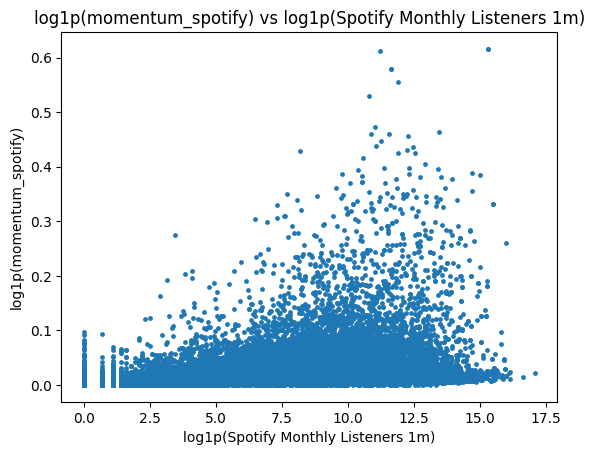

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


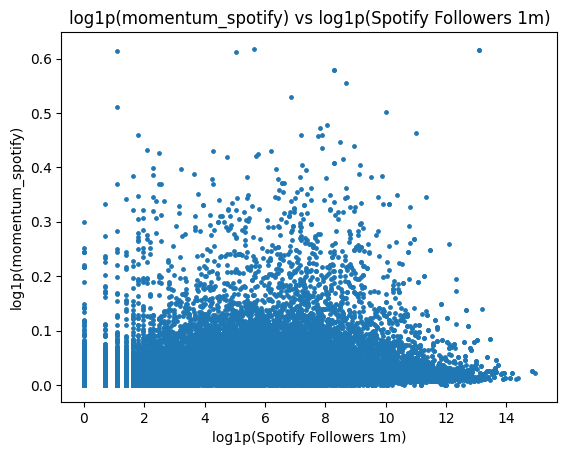

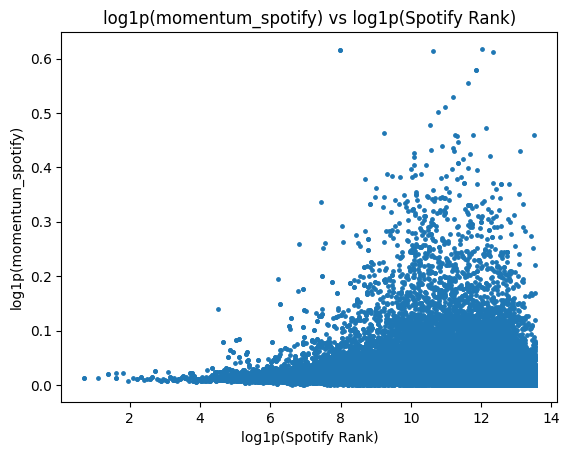

In [20]:
df["momentum_spotify"] = (df["Spotify Streams 1m"] / (df["Spotify Streams Total"] + 1))

target = "momentum_spotify"

features = ["Spotify Monthly Listeners 1m", "Spotify Followers 1m", "Spotify Rank"]  # example
for col in features:
    d = df[[col, target]].dropna()
    plt.figure()
    plt.scatter(np.log1p(d[col]), np.log1p(d[target]), s=6)
    plt.title(f"log1p({target}) vs log1p({col})")
    plt.xlabel(f"log1p({col})")
    plt.ylabel(f"log1p({target})")
    plt.show()

### Correlation with Momentum

In [21]:
df["momentum_spotify"] = df["Spotify Streams 1m"] / (df["Spotify Streams Total"] + 1)

In [22]:
num_cols = df.select_dtypes(include=np.number).columns

In [23]:
corr = df[num_cols].corr(numeric_only=True)["momentum_spotify"].sort_values(ascending=False)
corr.head(20), corr.tail(20)

(momentum_spotify                           1.000000
 YouTube Subscribers 1m                     0.122254
 TikTok Likes 1m                            0.114610
 Radio Airplay Rank                         0.088478
 Facebook Followers 1m                      0.079142
 YouTube Likes 1m                           0.065321
 TikTok Views 1m                            0.061379
 Beatport Track Performance Points 1m       0.052255
 YouTube Views 1m                           0.042568
 Spotify Monthly Listeners 1m               0.036652
 Spotify Followers 1m                       0.035027
 Instagram Followers 1m                     0.033810
 Spotify Monthly Listeners Total            0.027761
 Spotify Streams 1m                         0.025116
 Instagram Likes 1m                         0.023625
 TikTok Followers 1m                        0.019247
 SoundCloud Plays 1m                        0.009896
 SoundCloud Followers 1m                    0.003257
 Deezer Fans 1m                             0.

# Multivariate EDA

**In general:**
- Features are weak linear relationships. (Around 0.1 and under)


### Correlation Matrix

- Beatport ≈ 0, probably because it has 77% missing values
- Some features such as Viberate Rank and Spotify Rank are highly correlated. Probably because Viberate Rank is built on other ranks.


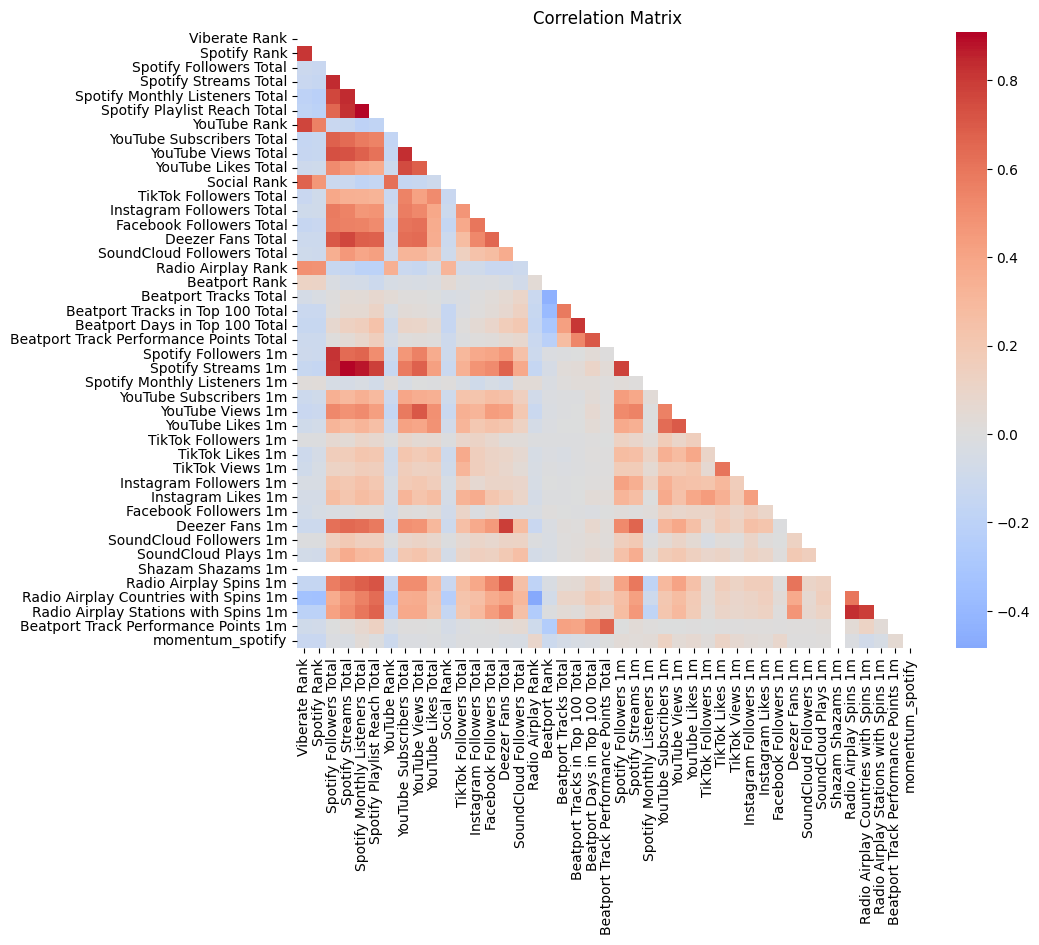

In [24]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


### Dimensionality Reduction (PCA)
Without rank (since it is inverted)

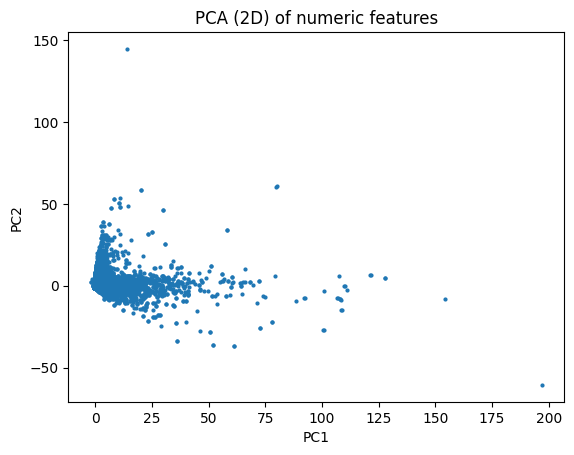

Explained variance ratio: [0.30541451 0.09421872] sum= 0.3996332389156511


In [25]:
num_cols = df.select_dtypes(include=np.number).columns

num_cols_no_rank = [
    col for col in num_cols
    if "Rank" not in col
]

X = df[num_cols_no_rank].copy()
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = preprocess.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=4)
plt.title("PCA (2D) of numeric features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_, "sum=", pca.explained_variance_ratio_.sum())

## Clustering (K-means)

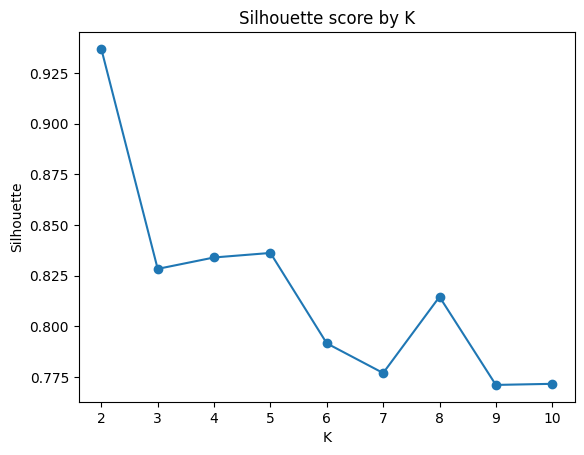

In [26]:
Z = X_scaled

scores = []
Ks = range(2, 11)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Z)
    score = silhouette_score(Z, labels)
    scores.append(score)

plt.figure()
plt.plot(list(Ks), scores, marker="o")
plt.title("Silhouette score by K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()

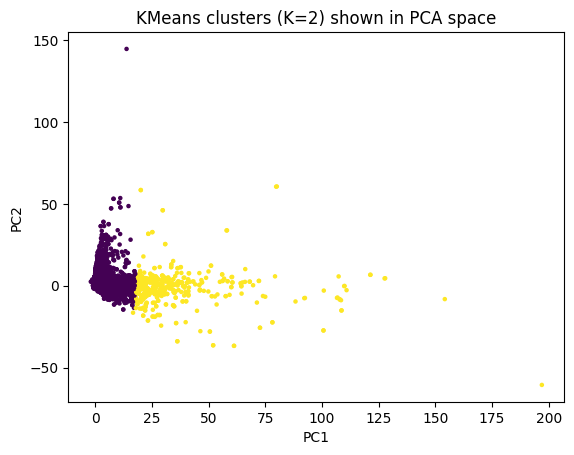

In [27]:
k = Ks[int(np.argmax(scores))]
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = km.fit_predict(Z)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=5)
plt.title(f"KMeans clusters (K={k}) shown in PCA space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()